In [3]:
pip install scanpy anndata matplotlib seaborn pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 94.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.

In [4]:
#Import Libraries & Load Data
import scanpy as sc
import pandas as pd
import numpy as np

# Fix the deprecation warning
sc.set_figure_params(dpi=80, facecolor='white')
sc.settings.verbosity = 3

# This automatically downloads the PBMC 3k dataset for you
# No manual file download needed
adata = sc.datasets.pbmc3k()

print(adata)

try downloading from url
https://exampledata.scverse.org/scanpy/pbmc3k_raw.h5ad
... this may take a while but only happens once


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [5]:
import scanpy as sc

sc.settings.verbosity = 3
sc.set_figure_params(dpi=80, facecolor='white')  # fixed deprecation warning

results_file = 'pbmc3k.h5ad'  # where we'll save results at the end

In [6]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [7]:
sc.pp.filter_cells(adata, min_genes=200)   # remove cells with fewer than 200 genes
sc.pp.filter_genes(adata, min_cells=3)     # remove genes found in fewer than 3 cells

print(adata)

filtered out 19024 genes that are detected in less than 3 cells
AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells'


In [8]:
# Flag mitochondrial genes (start with "MT-")
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True
)

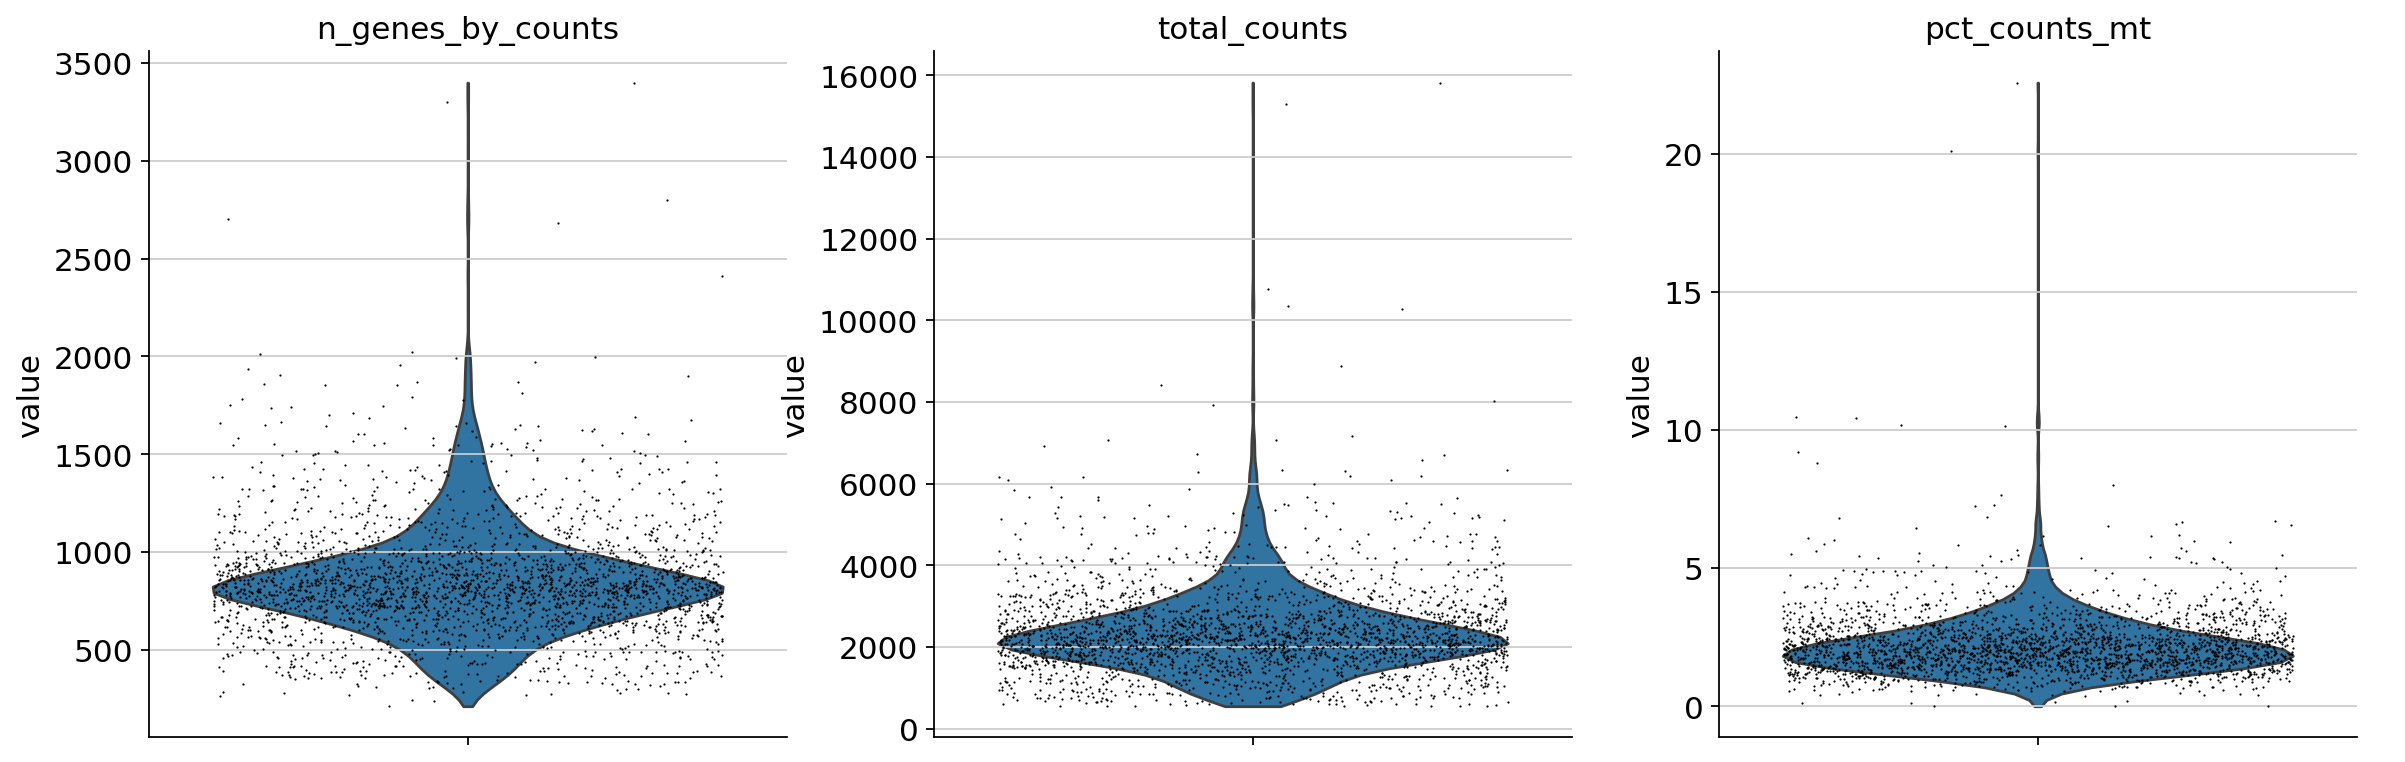

In [9]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True
)

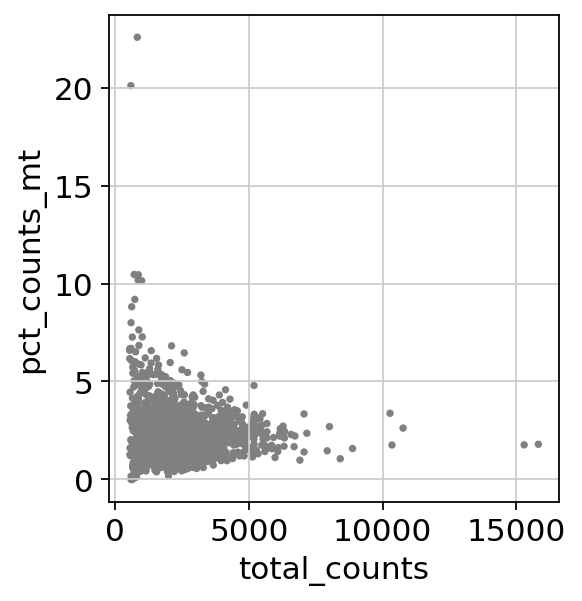

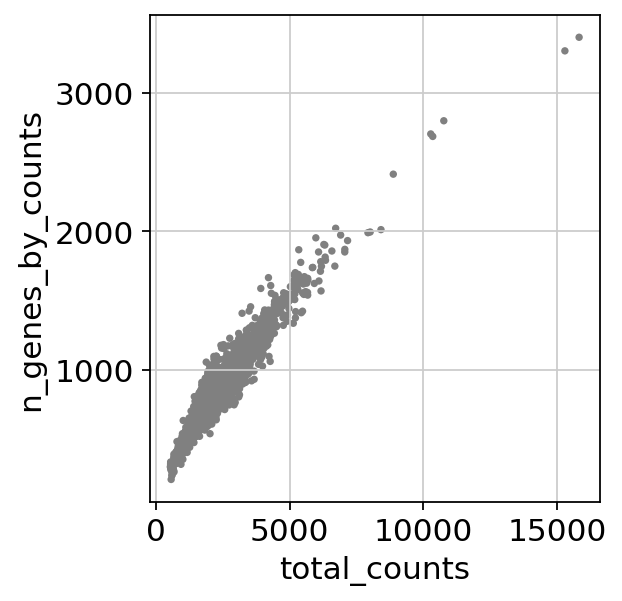

In [10]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [11]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"Cells remaining after QC: {adata.n_obs}")

Cells remaining after QC: 2638


In [12]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell


/tmp/ipykernel_7638/3052528762.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


    finished (0:00:04)


extracting highly variable genes
    finished (0:00:04)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


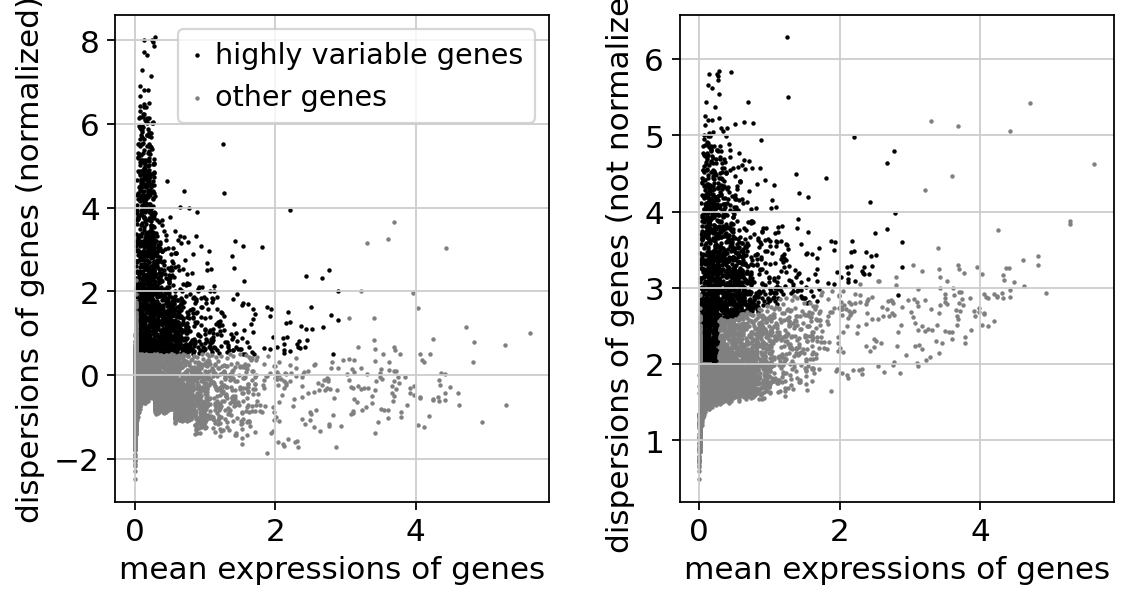

In [13]:
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

sc.pl.highly_variable_genes(adata)

In [14]:
# Store full data in .raw before filtering to HVGs
adata.raw = adata

# Keep only highly variable genes
adata = adata[:, adata.var.highly_variable]

print(f"Highly variable genes: {adata.n_vars}")

Highly variable genes: 1838


In [15]:
# Remove effect of total counts and % mitochondrial reads
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use


/tmp/ipykernel_7638/1653667938.py:2: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:658: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:658: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:02)


In [16]:
sc.pp.scale(adata, max_value=10)

computing PCA
    with n_comps=50
    finished (0:00:01)


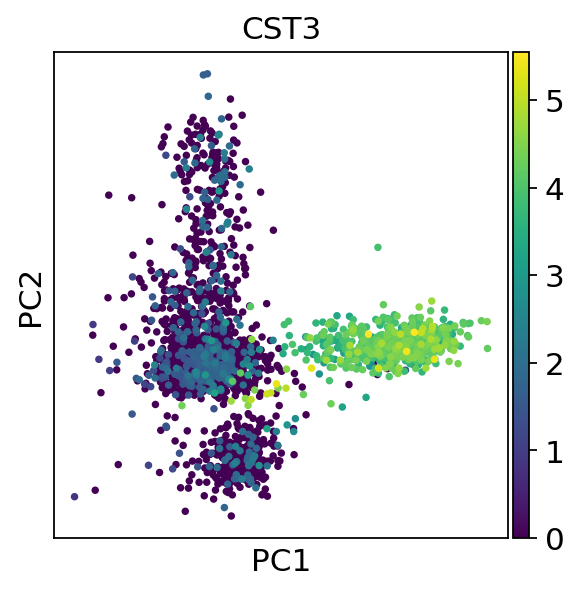

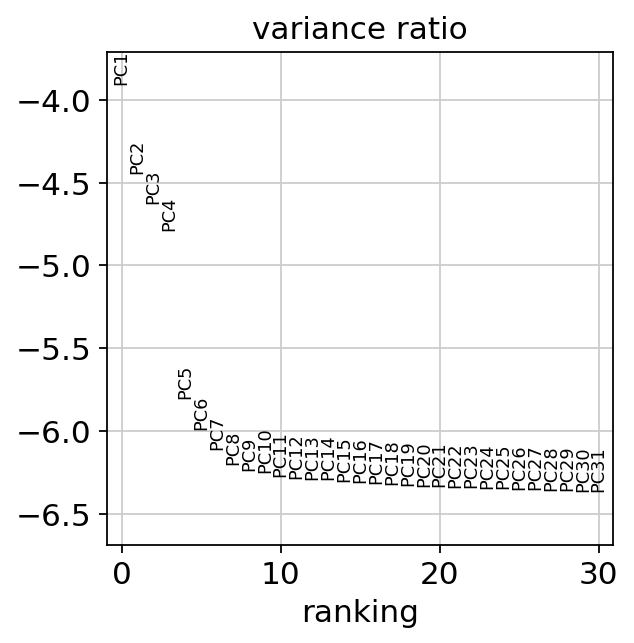

In [17]:
sc.tl.pca(adata, svd_solver='arpack')

sc.pl.pca(adata, color='CST3')  # CST3 is a monocyte marker

sc.pl.pca_variance_ratio(adata, log=True)

In [18]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:43)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


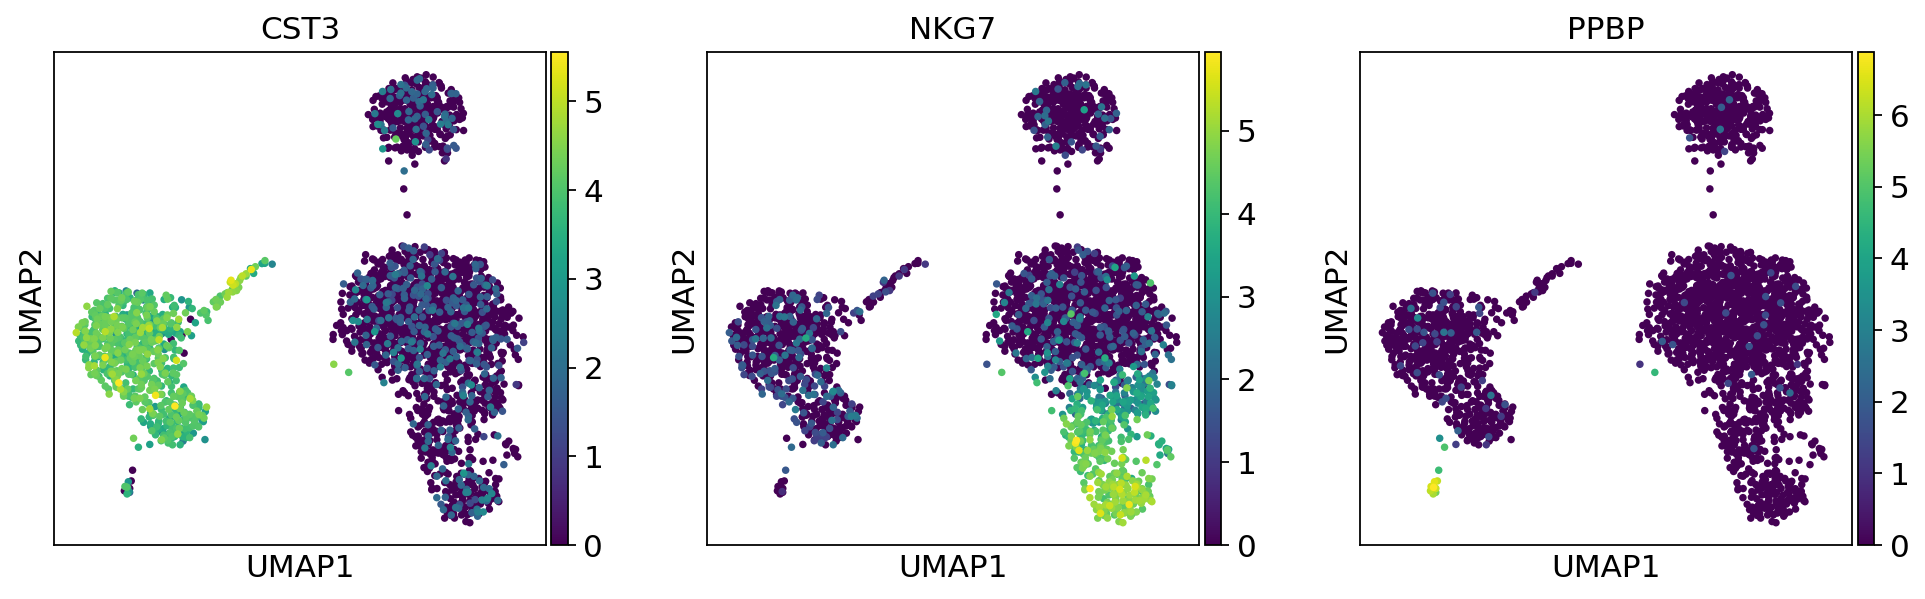

In [19]:
sc.tl.umap(adata)
sc.pl.umap(adata, color=['CST3', 'NKG7', 'PPBP'])

In [20]:
pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 88.3 MB/s eta 0:00:00


In [21]:
sc.tl.leiden(
    adata,
    resolution=0.9,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


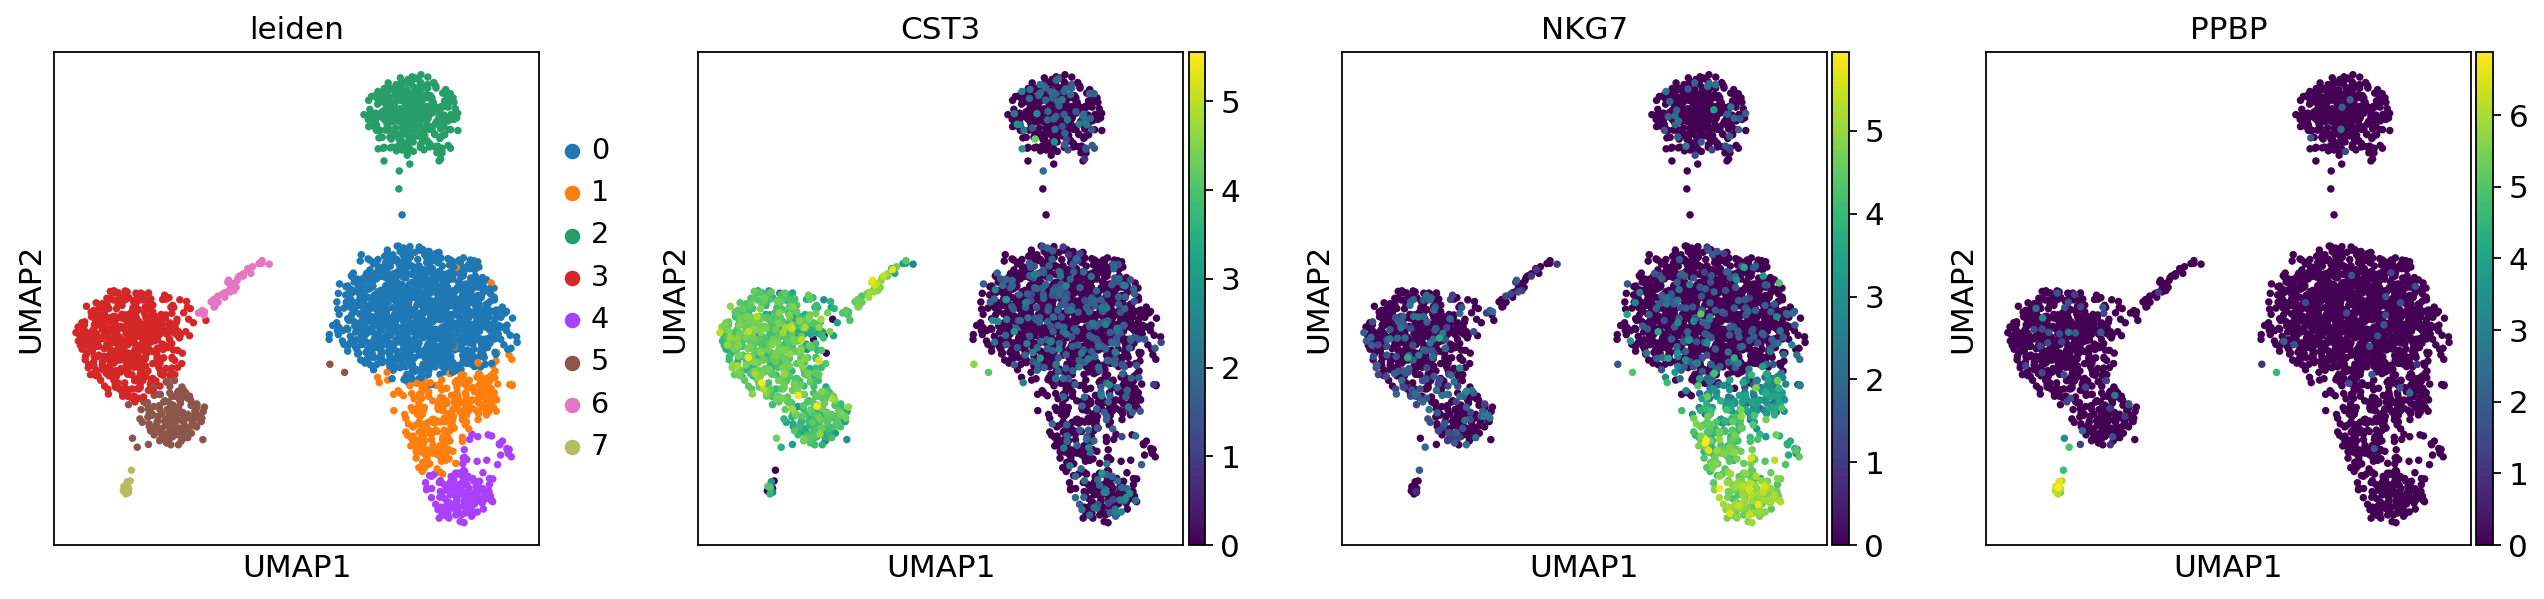

In [22]:
sc.pl.umap(adata, color=['leiden', 'CST3', 'NKG7', 'PPBP'])

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


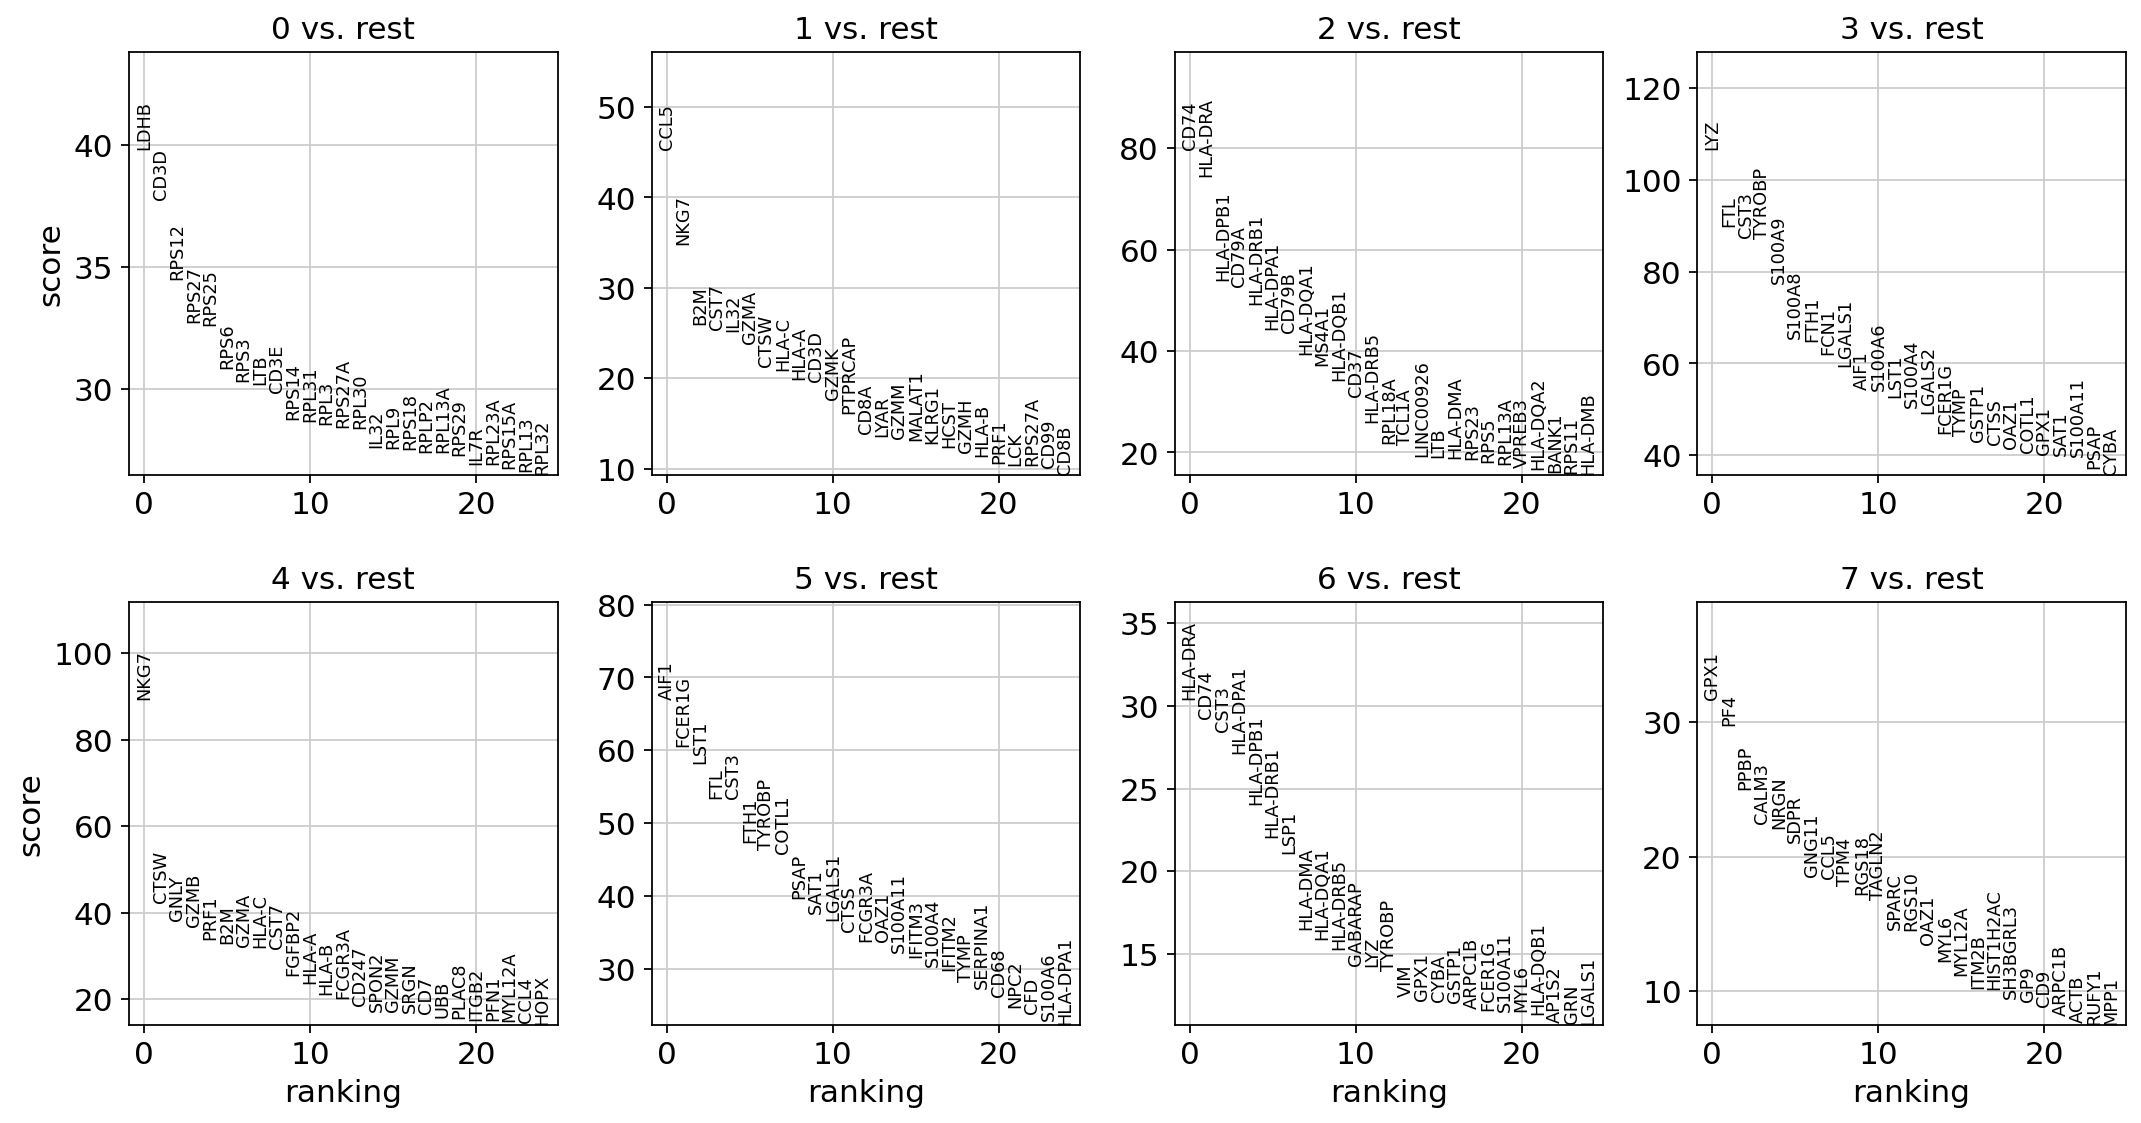

In [23]:
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:19)


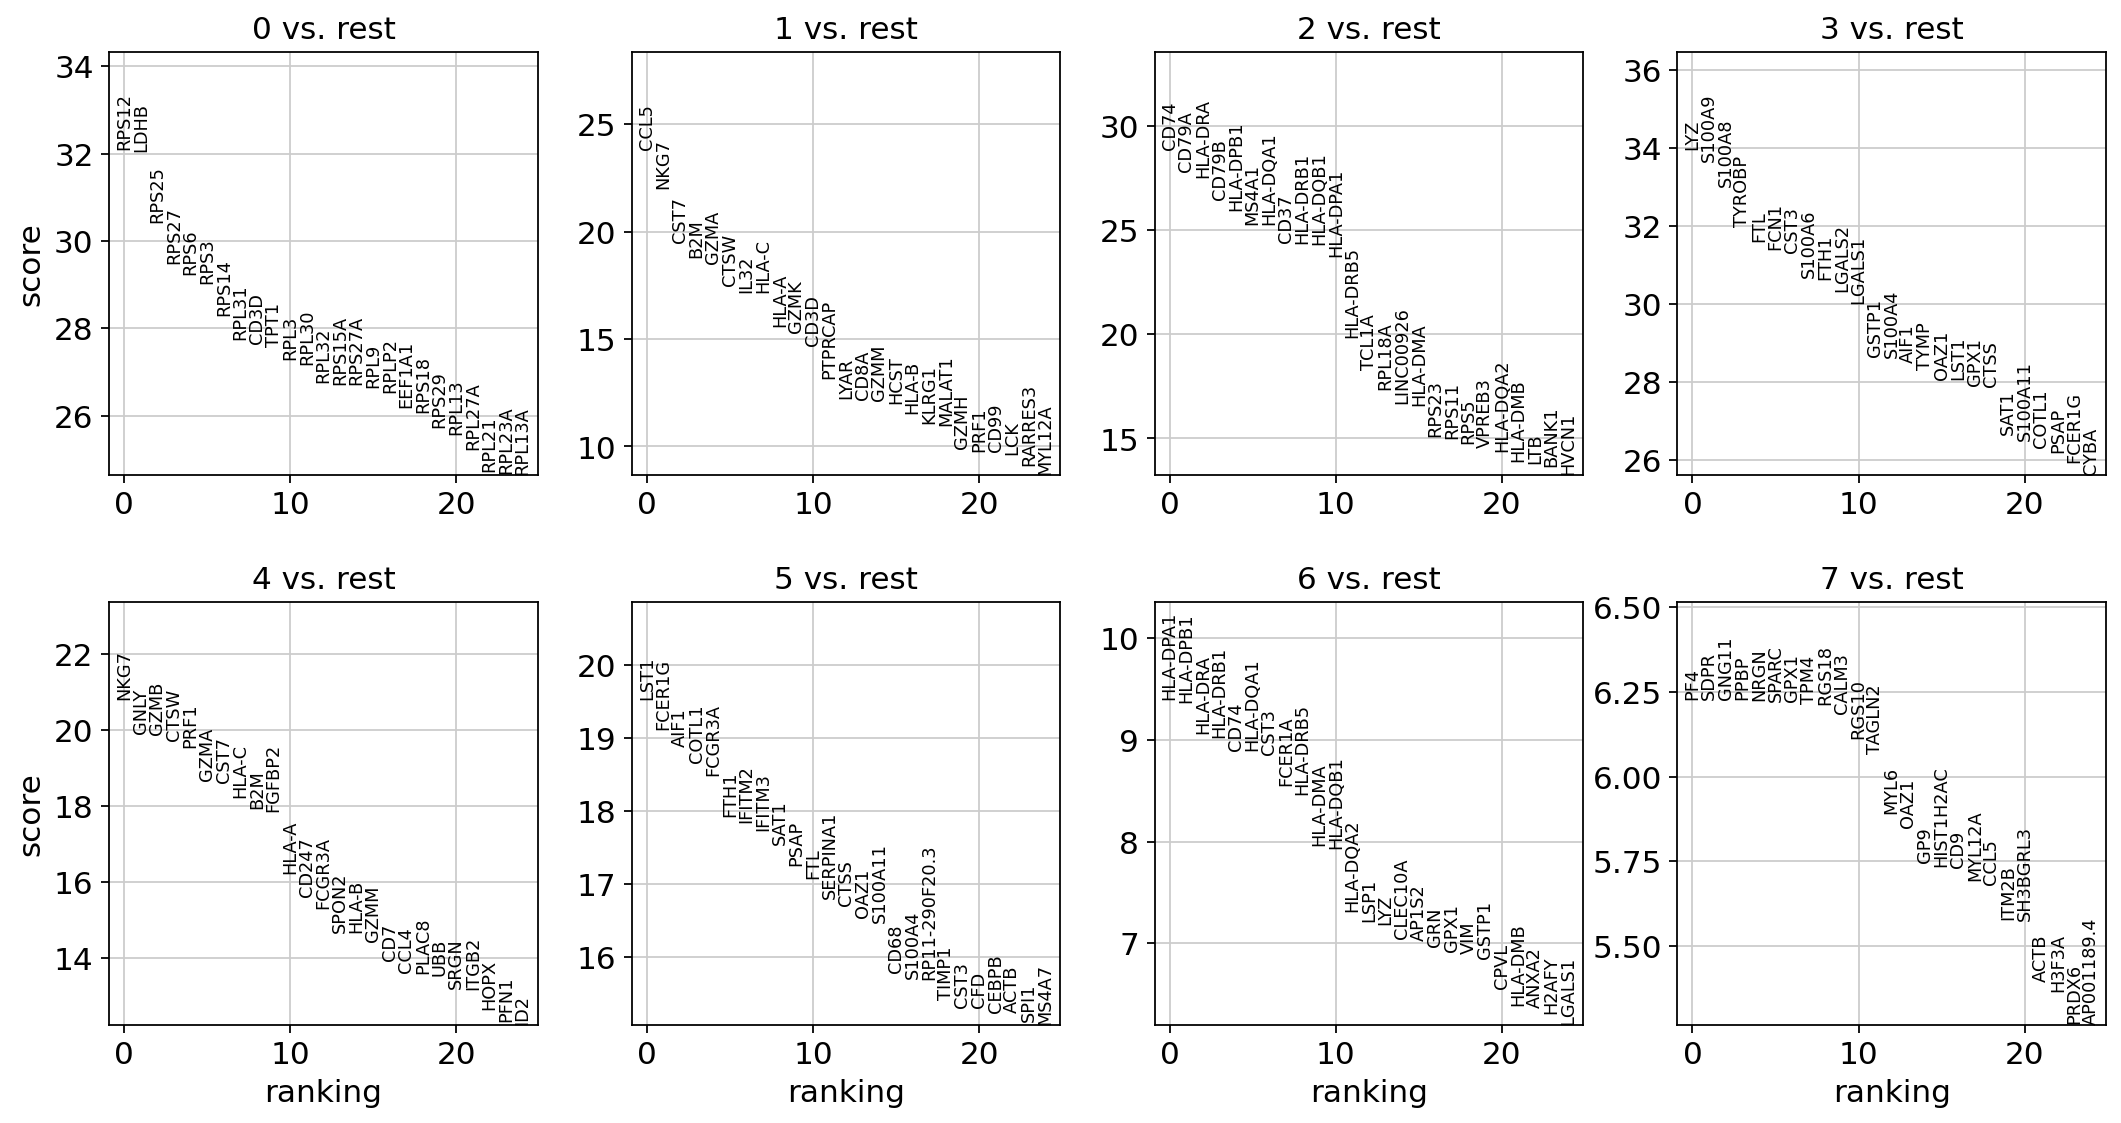

In [24]:
# Also try with Wilcoxon (more robust)
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

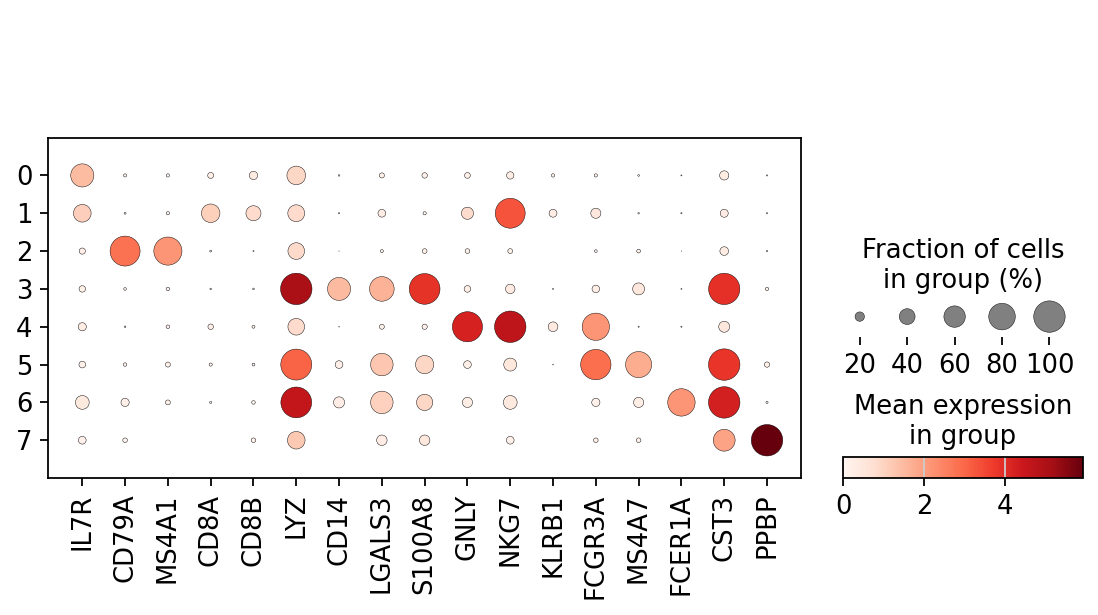

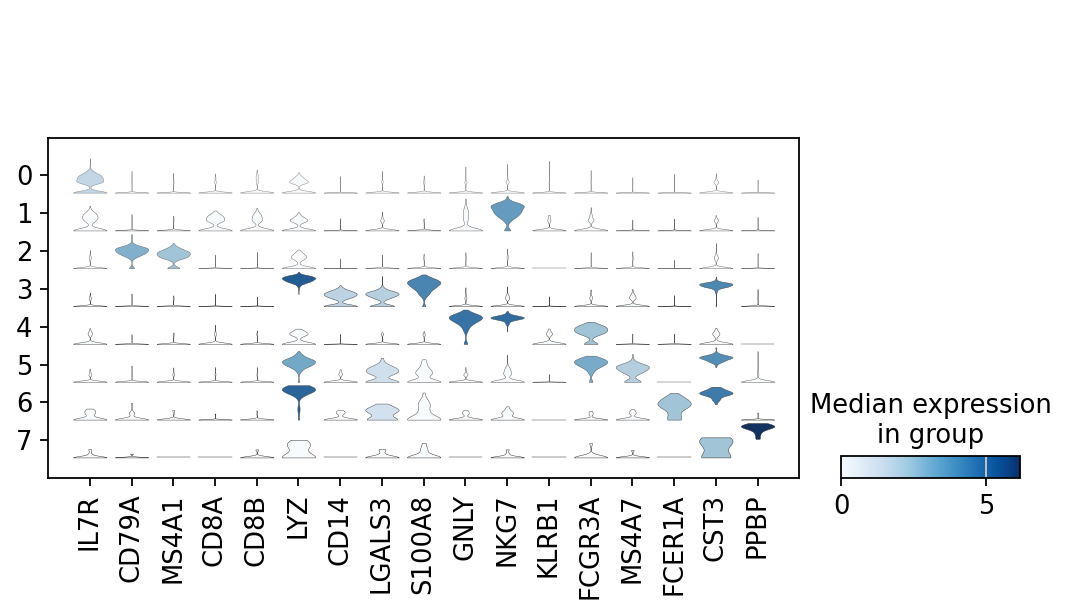

In [25]:
# Known PBMC marker genes for each cluster
marker_genes = ['IL7R', 'CD79A', 'MS4A1', 'CD8A', 'CD8B',
                'LYZ', 'CD14', 'LGALS3', 'S100A8', 'GNLY',
                'NKG7', 'KLRB1', 'FCGR3A', 'MS4A7',
                'FCER1A', 'CST3', 'PPBP']

sc.pl.dotplot(adata, marker_genes, groupby='leiden')
sc.pl.stacked_violin(adata, marker_genes, groupby='leiden')

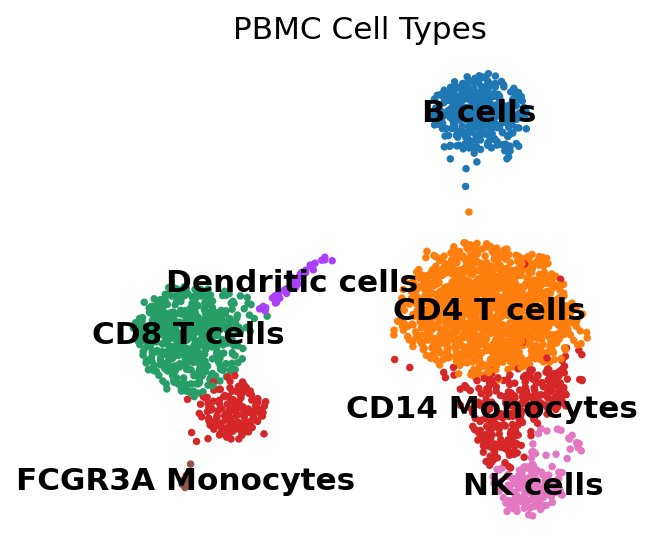

In [26]:
# Map cluster numbers to cell type names
cell_type_map = {
    '0': 'CD4 T cells',
    '1': 'CD14 Monocytes',
    '2': 'B cells',
    '3': 'CD8 T cells',
    '4': 'NK cells',
    '5': 'CD14 Monocytes',
    '6': 'Dendritic cells',
    '7': 'FCGR3A Monocytes',
    '8': 'Platelets',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map)

sc.pl.umap(adata, color='cell_type', legend_loc='on data',
           title='PBMC Cell Types', frameon=False)

In [27]:
adata.write(results_file)
print(f"Saved to {results_file}")

Saved to pbmc3k.h5ad
